# 2D single-stage flow training — reverse KL vs forward KL

This notebook trains one normalizing flow on a simple 2D multimodal target with each of
the two KL objectives and compares them by effective sample size (ESS). The workflow is
**100% energy-driven**: the target enters only through its potential $U_1$ (never through a
dataset), and the "target samples" required by the forward KL are manufactured on the fly
by annealed importance sampling (AIS).

Two conventions matter throughout:

- **No inverse map in training.** Each flow transform is differentiated only in its *native*
  direction: the reverse KL flow acts as $F$ (source $\to$ target) and the forward KL flow
  acts as $G$ (target $\to$ source). Inverses appear only at inference / data-generation time.
- **No epochs, no training set.** Every optimization step draws a fresh source batch
  (`N_BATCH`); the final ESS is measured on a fresh batch of `N_VALID` source samples.

In [1]:
import os
import sys
import time

# jflows is not pip-installed: put the repo root on the path (the kernel's
# working directory is example/, so the root is one level up)
_root = os.path.abspath("." if os.path.isdir("jflows") else "..")
if _root not in sys.path:
    sys.path.insert(0, _root)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

from jflows.flow import NSF
from jflows.loss import forward_KL, reverse_KL
from jflows.potential import Nlog_Gaussian, Nlog_Gaussian_Mixture
from jflows.utils import ais, compute_ESS, importance_weights

plt.rcParams.update({
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 11,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "mathtext.fontset": "cm", "font.family": "serif",
})

# boundary of the domain
SIGMA = 2.0            # standard deviation of the isotropic Gaussian source mu_0
PLT_LIM = 5.0          # half-width of the plot window
NSF_LIM = 5.0          # half-width of the NSF spline domain

# NSF flow architecture
BINS: int = 16                      # rational-quadratic spline bins per transform
TRANSFORMS: int = 4                 # autoregressive transforms stacked in the flow
HIDDEN_FEATURES = (64, 64)          # hidden widths of each conditioner MLP

# training parameters
N_VALID: int = 40000   # fresh source batch for the final ESS evaluation
N_BATCH: int = 2000    # source samples per training step
STEPS: int = 200       # Adam optimization steps
LR: float = 2e-3       # Adam learning rate

# single-rung AIS supplying the forward KL target samples
LADDER: int = 1        # one reweight + resample + rejuvenation hop
MC_STEP: float = 2e-3  # Langevin rejuvenation step size
MC_ITERS: int = 50     # Langevin rejuvenation steps per AIS call


def log(msg: str) -> None:
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)


log(f"jax {jax.__version__} | backend: {jax.default_backend()}")

[19:46:05] jax 0.10.2 | backend: gpu


## Source and target

The source is an isotropic Gaussian, written as a potential (every distribution in jflows
is the Gibbs measure of its energy, $\mu \propto e^{-U}$):

$$
\mu_0(x) \propto \exp\!\big(-U_0(x)\big), \qquad
U_0(x) = \frac{\lVert x \rVert^2}{2\sigma^2}, \qquad \sigma = 2 .
$$

The target is a three-mode Gaussian mixture placed like the Julia three-dot sign
(one mode on top, two below):

$$
\mu_1(y) \propto \sum_{k=1}^{3} w_k\,
\mathcal N\!\big(y \,;\, m_k,\, v\, I_2\big), \qquad
U_1(y) = -\log \mu_1(y) ,
$$

with equal weights, $m_1 = (0, 2.4)$, $m_2 = (-2.2, -1.4)$, $m_3 = (2.2, -1.4)$ and
$v = 0.3$. The three modes are separated by $\sim 8$ standard deviations, so a
mode-seeking objective can lose mass on this target while a mass-covering one should not.

In [2]:
# source: Gaussian U0
u0 = Nlog_Gaussian(mean=[0.0, 0.0], variance=[SIGMA**2, SIGMA**2])

# target: three-mode Gaussian mixture placed like the Julia three-dot sign
u1 = Nlog_Gaussian_Mixture(
    weights=[1.0, 1.0, 1.0],
    mean=[[0.0, 2.4], [-2.2, -1.4], [2.2, -1.4]],
    variance=[[0.3, 0.3], [0.3, 0.3], [0.3, 0.3]],
)

## Flow and optimizer

Both methods train the same architecture: a Neural Spline Flow on the box
$[-L, L]^2$ ($L = $ `NSF_LIM`), initialised at the identity (`zeros()`). The optimizer is a
plain Adam written against the flow's parameter pytree. One JAX-specific rule: the step
counter must enter the jitted update as a **traced array** — a Python integer would be a
static argument under `eqx.filter_jit` and would recompile the step at every iteration.

In [3]:
def new_flow(key):
    flow = NSF(key, a=[-NSF_LIM, -NSF_LIM], b=[+NSF_LIM, +NSF_LIM], bins=BINS,
               transforms=TRANSFORMS, hidden_features=HIDDEN_FEATURES)
    return flow.zeros()


def adam_update(params, m, v, grads, t):
    m = jax.tree.map(lambda m_, g: 0.9 * m_ + 0.1 * g, m, grads)
    v = jax.tree.map(lambda v_, g: 0.999 * v_ + 0.001 * g * g, v, grads)
    m_hat = jax.tree.map(lambda x: x / (1 - 0.9**t), m)
    v_hat = jax.tree.map(lambda x: x / (1 - 0.999**t), v)
    params = jax.tree.map(lambda p, mh, vh: p - LR * mh / (jnp.sqrt(vh) + 1e-8),
                          params, m_hat, v_hat)
    return params, m, v

## Method 1 — reverse KL (source data, mode-seeking)

The flow acts as the forward map $F$: source $\to$ target, with pushforward
$\nu = F_\# \mu_0$. Up to an additive constant,

$$
\mathrm{KL}\big(\nu \,\big\|\, \mu_1\big)
= \mathbb E_{x \sim \mu_0}
\Big[\, U_1\big(F(x)\big) \;-\; \log \big\lvert \det J_F(x) \big\rvert \,\Big]
+ \text{const},
$$

estimated per sample by `reverse_KL(x, u1, F, type='F')` on a fresh batch $x \sim \mu_0$ each step
(the loss returns the full $[N]$ vector; we reduce with `.mean()`). Only source samples and
target *energy evaluations* are needed — this is the cheap objective, but it is
mode-seeking: a mode that $\nu$ never visits contributes no gradient.

In [4]:
def train_reverse(key):
    flow = new_flow(jax.random.fold_in(key, 0))
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)

    @eqx.filter_jit
    def step(params, m, v, t, key):
        x = u0.samples(key, N_BATCH)

        def loss_fn(p):
            return reverse_KL(x, u1, eqx.combine(p, static), type="F").mean()

        loss, grads = jax.value_and_grad(loss_fn)(params)
        params, m, v = adam_update(params, m, v, grads, t)
        return params, m, v, loss

    for i in range(1, STEPS + 1):
        k = jax.random.fold_in(key, i)
        params, m, v, loss = step(params, m, v, jnp.asarray(i, dtype=jnp.float32), k)
        if i % 50 == 0 or i == 1:
            log(f"[reverse KL] step {i:>3}/{STEPS}   loss = {float(loss):+.4e}")
    return eqx.combine(params, static)


flow_F = train_reverse(jax.random.key(0))

[19:46:09] [reverse KL] step   1/200   loss = +6.6767e+00


[19:46:09] [reverse KL] step  50/200   loss = +3.0743e+00


[19:46:09] [reverse KL] step 100/200   loss = +3.0685e+00


[19:46:09] [reverse KL] step 150/200   loss = +2.8742e+00


[19:46:09] [reverse KL] step 200/200   loss = +2.8052e+00


## Method 2 — forward KL with AIS-supplied target data (mass-covering)

The flow acts as the inverse-direction map $G$: target $\to$ source, with proposal
$\nu = (G^{-1})_\# \mu_0$. Up to an additive constant,

$$
\mathrm{KL}\big(\mu_1 \,\big\|\, \nu\big)
= \mathbb E_{y \sim \mu_1}
\Big[\, U_0\big(G(y)\big) \;-\; \log \big\lvert \det J_G(y) \big\rvert \,\Big]
+ \text{const},
$$

estimated by `forward_KL(y, u0, G, type='G')` — but it needs samples $y \sim \mu_1$, the very thing
we are trying to produce. Each step breaks the circularity with **single-rung AIS**
(`ais` with `type='G'`, `ladder = 1`) on the *current* flow: push the fresh source batch forward,
compute the self-normalised importance weights of the flow proposal against the target,

$$
\log w(y) = -\,U_1(y) \;+\; U_0(x) \;+\; \log \big\lvert \det J_F(x) \big\rvert,
\qquad x = F^{-1}(y),
$$

multinomially resample by $w$, and rejuvenate with `MC_ITERS` Langevin steps **at the
target** $\mu_1$. The result is a batch approximately distributed as $\mu_1$; no gradient
flows through this data generation, and $G$ is still differentiated only in its native
direction.

In [5]:
def train_forward(key):
    flow = new_flow(jax.random.fold_in(key, 0))
    params, static = eqx.partition(flow, eqx.is_inexact_array)
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)

    @eqx.filter_jit
    def step(params, m, v, t, key):
        key_x, key_ais = jax.random.split(key)
        x = u0.samples(key_x, N_BATCH)
        # target samples from single-rung AIS on the CURRENT flow proposal
        G_now = eqx.combine(params, static)
        y_mu = ais(key_ais, x, u0, u1, G_now, type="G",
                   ladder=LADDER, step=MC_STEP, iters=MC_ITERS)
        y_mu = jax.lax.stop_gradient(y_mu)

        def loss_fn(p):
            return forward_KL(y_mu, u0, eqx.combine(p, static), type="G").mean()

        loss, grads = jax.value_and_grad(loss_fn)(params)
        params, m, v = adam_update(params, m, v, grads, t)
        return params, m, v, loss

    for i in range(1, STEPS + 1):
        k = jax.random.fold_in(key, i)
        params, m, v, loss = step(params, m, v, jnp.asarray(i, dtype=jnp.float32), k)
        if i % 50 == 0 or i == 1:
            log(f"[forward KL] step {i:>3}/{STEPS}   loss = {float(loss):+.4e}")
    return eqx.combine(params, static)


flow_G = train_forward(jax.random.key(1))

[19:46:11] [forward KL] step   1/200   loss = +8.8175e-01


[19:46:11] [forward KL] step  50/200   loss = -4.1393e-01


[19:46:11] [forward KL] step 100/200   loss = -4.7437e-01


[19:46:11] [forward KL] step 150/200   loss = -4.1565e-01


[19:46:11] [forward KL] step 200/200   loss = -4.4084e-01


## Evaluation — flow importance sampling and ESS

Because the flow is a bijection, every pushforward sample carries an exact importance
weight against the unnormalized target, and the quality of the fit is summarized by the
effective sample size

$$
\mathrm{ESS}
= \frac{\big(\sum_{i=1}^{N} w_i\big)^2}{N \sum_{i=1}^{N} w_i^{2}} \;\in\; (0, 1],
$$

computed here on a fresh batch of `N_VALID` source samples (weights from
`importance_weights` with `type='F'` for the $F$ flow and `type='G'` for the $G$ flow).
An ESS near 1 means the proposal matches the target on the support it reaches — with the
usual caveat that a *silently missed mode* can leave the ESS high while mass is absent.

In [6]:
x_valid = u0.samples(jax.random.key(2), N_VALID)
ess_F = float(compute_ESS(importance_weights(x_valid, u0, u1, flow_F, type="F")))
ess_G = float(compute_ESS(importance_weights(x_valid, u0, u1, flow_G, type="G")))
log(f"[reverse KL] final ESS = {ess_F:.4f}   (N_VALID = {N_VALID})")
log(f"[forward KL] final ESS = {ess_G:.4f}   (N_VALID = {N_VALID})")

[19:46:15] [reverse KL] final ESS = 0.9055   (N_VALID = 40000)


[19:46:15] [forward KL] final ESS = 0.9466   (N_VALID = 40000)


## Pushforward samples

Each panel shows the target energy $U_1$ (light background with gray level lines), 5000
source samples for visual context (gray), and the `N_VALID` pushforward samples of one
method — blue for reverse KL ($y = F(x)$), red for forward KL ($y = G^{-1}(x)$) — with the
final ESS in the title.

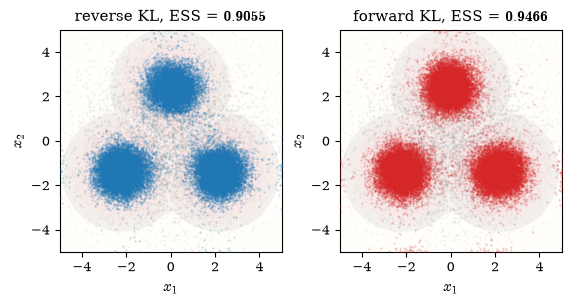

In [7]:
n = 300
g = jnp.linspace(-PLT_LIM, PLT_LIM, n)
X1, X2 = jnp.meshgrid(g, g, indexing="xy")
U_np = np.asarray(u1(jnp.stack([X1.ravel(), X2.ravel()], axis=-1)).reshape(n, n))
levels = np.linspace(U_np.min(), U_np.min() + 12.0, 50)
cmap = LinearSegmentedColormap.from_list("light_yellow_red", ["#fffefa", "#ffe5e5"])

y_F = flow_F(x_valid)              # F pushes source samples forward
y_G = flow_G.inv(x_valid)          # G's inverse pushes source samples forward
prior = np.asarray(u0.samples(jax.random.key(3), 5000))  # source Gaussian, visual context

fig, axes = plt.subplots(1, 2, figsize=(5.6, 3.0), constrained_layout=True)
for ax, y, color, name, ess in (
    (axes[0], y_F, "#1F77B4A0", "reverse KL", ess_F),
    (axes[1], y_G, "#D62728A0", "forward KL", ess_G),
):
    ax.contourf(np.asarray(X1), np.asarray(X2), U_np, levels=levels,
                cmap=cmap.reversed(), extend="max")
    ax.contour(np.asarray(X1), np.asarray(X2), U_np, levels=levels,
               colors="gray", linewidths=0.2, alpha=0.2)
    ax.scatter(prior[:, 0], prior[:, 1], s=0.04, alpha=0.3, color="gray", zorder=5)
    ax.scatter(np.asarray(y[:, 0]), np.asarray(y[:, 1]), s=0.2, alpha=0.3,
               color=color, zorder=10, rasterized=True)
    ax.set_title(f"{name}, ESS = $\\mathbf{{{ess:.4f}}}$")
    ax.set_xlim(-PLT_LIM, PLT_LIM)
    ax.set_ylim(-PLT_LIM, PLT_LIM)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
plt.show()

## Reading the result

Both flows populate all three modes here, and the AIS-fed forward KL ends with the higher
ESS: the single AIS rung keeps supplying (approximately) target-distributed data even as
the modes separate, while the reverse KL pays its mode-seeking tax as barriers grow. On a
harder target — farther modes, or modes the initial proposal never reaches — the reverse
objective can collapse entirely, and the forward objective inherits whatever the AIS chain
covers; that regime (and the regularization that addresses it) is the subject of the
X-regularization paper this example's conventions come from.